In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

In [2]:
irna_res = pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/irnaseq_results/control_vs_cpi.txt", sep="\t")

In [3]:
irna_res

,RefSeq,Log2_FC,logCPM,Pval,Padj,Chr,Strand,Start,End,Symbol,txLength,countLength,X.usr.users.papantonis1.aman.rnaseq_data.star_results.S59_Aligned.sortedByCoord.out.bam,X.usr.users.papantonis1.aman.rnaseq_data.star_results.S60_Aligned.sortedByCoord.out.bam,X.usr.users.papantonis1.aman.rnaseq_data.star_results.S57_Aligned.sortedByCoord.out.bam,X.usr.users.papantonis1.aman.rnaseq_data.star_results.S58_Aligned.sortedByCoord.out.bam
0,NM_000015,0.000000,-3.431524,1.000000,1.000000,chr8,+,18391281,18401215,NAT2,9934,8537,-3.431524,-3.431524,-3.431524,-3.431524
1,NM_000019,0.246247,5.119186,0.142477,0.772378,chr11,+,108121566,108147601,ACAT1,26035,21217,4.937026,5.044678,5.138230,5.331148
2,NM_000023,-0.167792,-2.430929,1.000000,1.000000,chr17,+,50166004,50175928,SGCA,9924,6642,-3.431524,-1.735318,-1.942605,-3.431524
3,NM_000025,0.000000,-3.431524,1.000000,1.000000,chr8,-,37962989,37966599,ADRB3,3610,734,-3.431524,-3.431524,-3.431524,-3.431524
4,NM_000033,0.161087,4.760234,0.355904,0.982565,chrX,+,153724855,153744755,ABCD1,19900,16088,4.605581,4.748493,4.810379,4.866476
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14660,NM_213649,0.036623,5.744029,0.821377,1.000000,chr10,-,119140766,119165714,SFXN4,24948,20741,5.841364,5.597684,5.637694,5.878698
14661,NM_213656,0.000000,-3.431524,1.000000,1.000000,chr17,-,40958416,40966948,KRT39,8532,6567,-3.431524,-3.431524,-3.431524,-3.431524
14662,NM_213674,-0.476144,0.676702,0.243761,0.889453,chr9,-,35681992,35690056,TPM2,8064,5790,0.978815,0.767261,0.240234,0.621600
14663,NM_213725,0.051223,6.247870,0.788584,1.000000,chr15,+,69452817,69456205,RPLP1,3388,1456,6.216489,6.227923,5.918969,6.559854


In [4]:
sig = irna_res.loc[irna_res["Padj"].lt(0.05) & irna_res["Log2_FC"].abs().gt(1)]
sig.describe()

,Log2_FC,logCPM,Pval,Padj,Start,End,txLength,countLength,X.usr.users.papantonis1.aman.rnaseq_data.star_results.S59_Aligned.sortedByCoord.out.bam,X.usr.users.papantonis1.aman.rnaseq_data.star_results.S60_Aligned.sortedByCoord.out.bam,X.usr.users.papantonis1.aman.rnaseq_data.star_results.S57_Aligned.sortedByCoord.out.bam,X.usr.users.papantonis1.aman.rnaseq_data.star_results.S58_Aligned.sortedByCoord.out.bam
count,31.000000,31.000000,3.100000e+01,3.100000e+01,3.100000e+01,3.100000e+01,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000
mean,-0.058389,2.214822,5.962275e-05,9.504810e-03,7.333497e+07,7.340766e+07,72685.580645,65694.000000,2.088936,1.915415,2.013608,1.996985
std,2.017502,2.011165,8.220877e-05,1.102524e-02,6.447619e+07,6.448826e+07,161988.978089,152289.711818,2.468415,2.603756,2.006660,1.927616
min,-6.192230,-1.729825,3.910403e-11,5.734606e-07,6.493640e+05,6.678300e+05,2527.000000,708.000000,-2.519992,-3.431524,-3.431524,-3.431524
25%,-1.221441,1.161259,1.551945e-06,8.322678e-04,1.278234e+07,1.284412e+07,4025.000000,1845.000000,0.498186,0.474647,0.911719,1.241746
50%,-1.048810,2.081370,1.258757e-05,4.102151e-03,5.755165e+07,5.756833e+07,11778.000000,7311.000000,1.944487,1.956966,1.800653,2.038809
75%,1.383502,3.312259,1.057359e-04,1.811424e-02,1.102866e+08,1.106714e+08,46787.500000,40129.000000,3.539037,3.296696,3.045222,3.221878
max,4.072303,7.484298,2.588723e-04,3.245716e-02,2.192098e+08,2.192190e+08,703986.000000,638289.000000,7.739256,8.054995,7.238570,6.417981


In [5]:
len(sig)

31

In [6]:
sig_up = irna_res.loc[
    (irna_res["Padj"] < 0.05) & (irna_res["Log2_FC"] > 1)
]

len(sig_up)

14

In [7]:
sig_down = irna_res.loc[
    (irna_res["Padj"] < 0.05) & (irna_res["Log2_FC"] < -1)
]

len(sig_down)

17

---

In [8]:
#install.packages("readr")

In [9]:
library(EnhancedVolcano)
library(readr)

# Read your output
irna <- read_tsv("/usr/users/papantonis1/aman/rnaseq_data/irnaseq_results/control_vs_cpi.txt")

# Basic volcano plot
EnhancedVolcano(irna,
    lab = irna$Symbol,
    x = 'Log2_FC',
    y = 'Padj',
    pCutoff = 0.05,
    FCcutoff = 1,
    xlim = c(-6, 6),
    title = 'Intron Retention: CPI vs Control' # Intronic reads - CPI vs Control:DLD1
)

SyntaxError: invalid syntax (1390236658.py, line 9)

---

In [ ]:
sample_cols = [col for col in irna_res.columns if col.startswith("X.usr")]
sig_counts = sig[sample_cols]

sample_cols

['X.usr.users.papantonis1.aman.rnaseq_data.star_results.S59_Aligned.sortedByCoord.out.bam',
 'X.usr.users.papantonis1.aman.rnaseq_data.star_results.S60_Aligned.sortedByCoord.out.bam',
 'X.usr.users.papantonis1.aman.rnaseq_data.star_results.S57_Aligned.sortedByCoord.out.bam',
 'X.usr.users.papantonis1.aman.rnaseq_data.star_results.S58_Aligned.sortedByCoord.out.bam']

In [ ]:
sig_counts

,X.usr.users.papantonis1.aman.rnaseq_data.star_results.S59_Aligned.sortedByCoord.out.bam,X.usr.users.papantonis1.aman.rnaseq_data.star_results.S60_Aligned.sortedByCoord.out.bam,X.usr.users.papantonis1.aman.rnaseq_data.star_results.S57_Aligned.sortedByCoord.out.bam,X.usr.users.papantonis1.aman.rnaseq_data.star_results.S58_Aligned.sortedByCoord.out.bam
325,-2.519992,-3.431524,-0.240825,0.079450
579,1.274990,0.767261,3.008470,2.198817
888,1.913550,1.749878,0.386017,0.809651
1322,-0.013136,-0.287205,1.654828,1.441865
1674,3.571973,3.292885,4.790874,4.718801
2659,0.681116,0.722572,1.800653,2.342837
3684,4.701520,4.653484,3.388919,3.852452
3880,2.388800,2.373038,1.071915,1.383837
4124,3.239194,2.859351,1.917179,1.383837
4773,4.244580,4.199013,3.074487,2.417043


In [ ]:
len(sig_counts)

31

In [ ]:
# transformation for visualization

# log2(count + 1)
log_counts = np.log2(sig_counts + 1)

# z-score normalization (row-wise)
log_counts_z = log_counts.sub(log_counts.mean(axis=1), axis=0)  # Z-score normalization

# Drop rows with NaNs or infinite values
log_counts_z = log_counts_z.replace([np.inf, -np.inf], np.nan).dropna()

/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log2
  result = func(self.values, **kwargs)


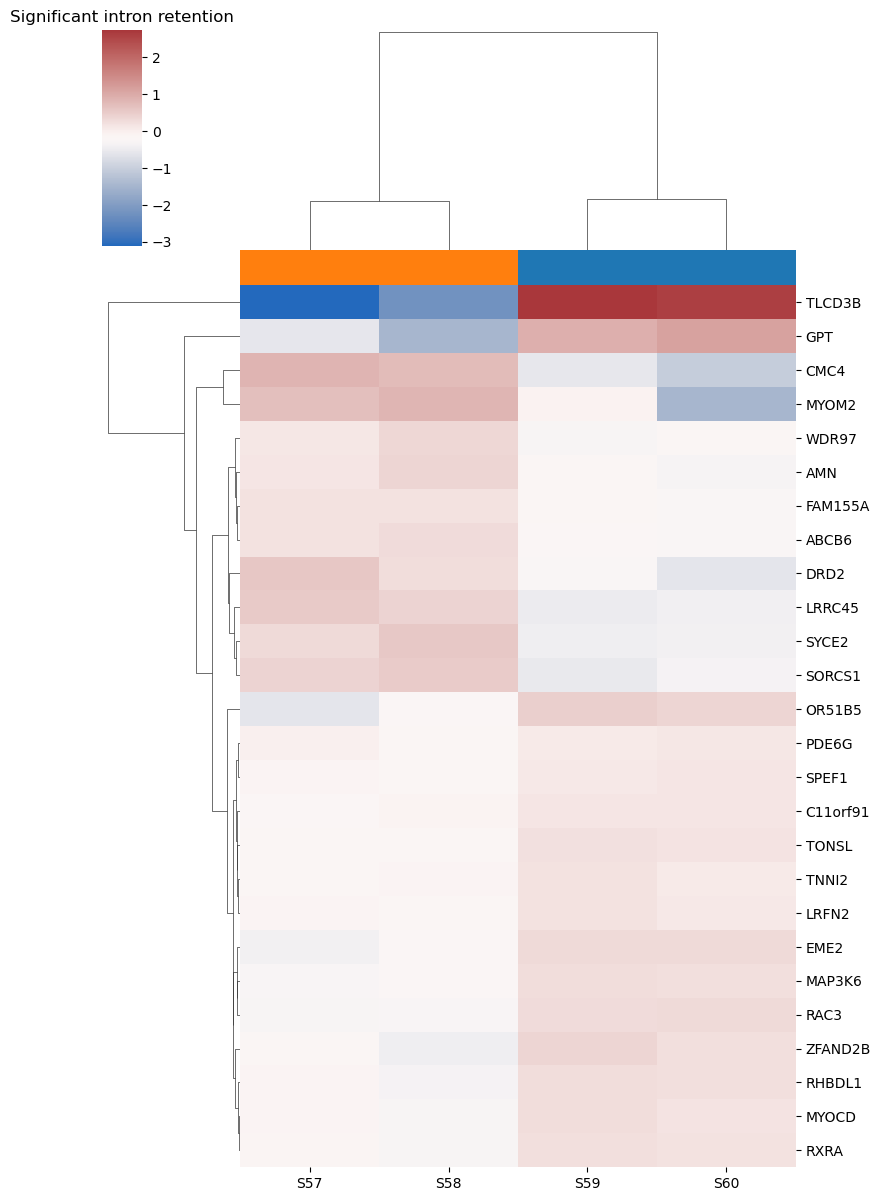

In [ ]:
# Extract sample names robustly
clean_col_labels = [
    re.search(r'S\d+', col).group(0)
    if re.search(r'S\d+', col) else col
    for col in log_counts_z.columns
]

# Map conditions
sample_to_condition = {
    'S55': 'AuxinCPI',
    'S56': 'AuxinCPI',
    'S57': 'CPI',
    'S58': 'CPI',
    'S59': 'control',
    'S60': 'control'
}

# Colors for conditions
condition_colors = {
    'control': '#1f77b4',     # blue
    'CPI': '#ff7f0e',          # orange
    'AuxinCPI': '#2ca02c'      # green
}

# Assign colors based on condition
col_colors = [condition_colors[sample_to_condition[s]] for s in clean_col_labels]

# Set clean names to columns of log_counts_z
log_counts_z.columns = clean_col_labels

sns.clustermap(
    log_counts_z,
    cmap='vlag',
    col_cluster=True,
    row_cluster=True,
    xticklabels=True,
    yticklabels=sig['Symbol'].values,
    col_colors=col_colors,
    figsize=(8, 12)
)
plt.title("Significant intron retention")
plt.show()


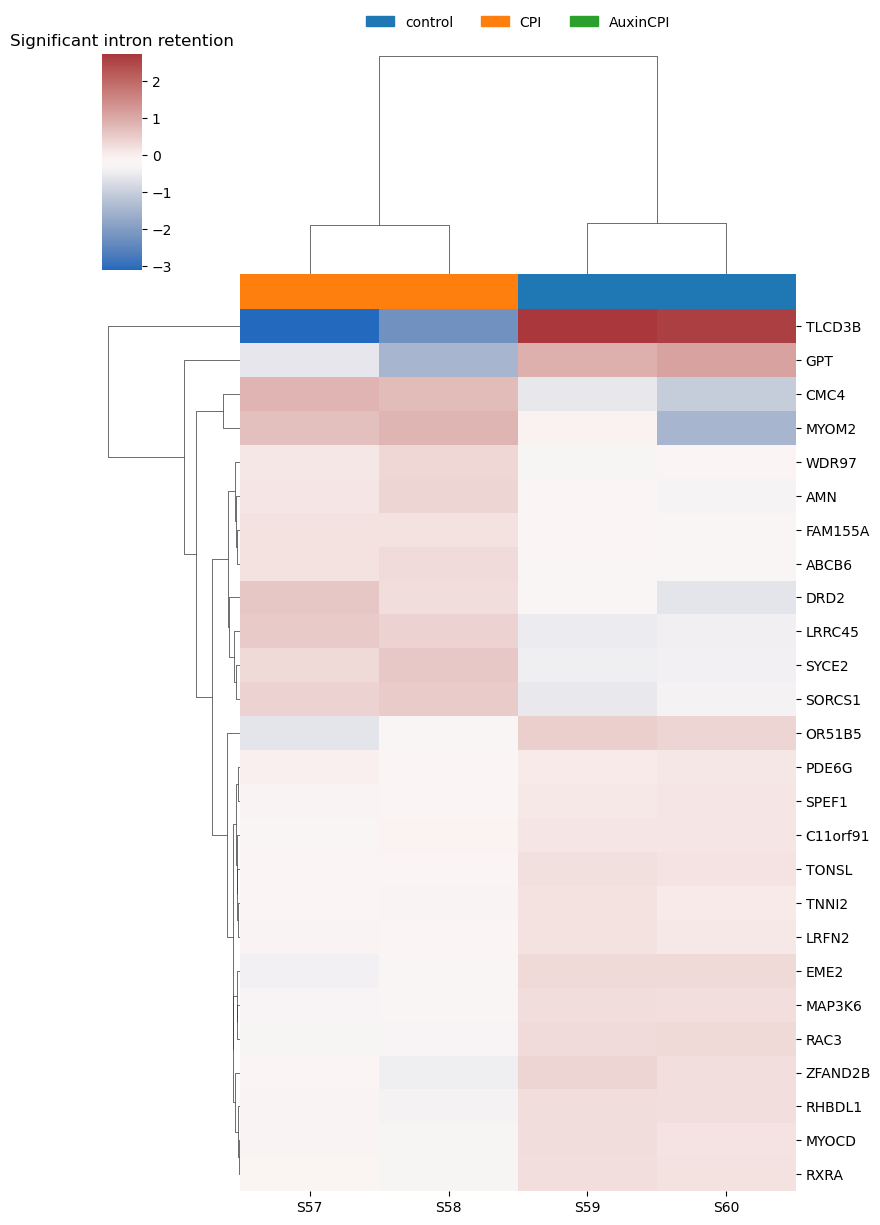

In [ ]:
import re
import matplotlib.patches as mpatches

# Extract sample names robustly
clean_col_labels = [
    re.search(r'S\d+', col).group(0)
    if re.search(r'S\d+', col) else col
    for col in log_counts_z.columns
]


# Map conditions
sample_to_condition = {
    'S55': 'AuxinCPI',
    'S56': 'AuxinCPI',
    'S57': 'CPI',
    'S58': 'CPI',
    'S59': 'control',
    'S60': 'control'
}

condition_colors = {
    'control': '#1f77b4',
    'CPI': '#ff7f0e',
    'AuxinCPI': '#2ca02c'
}

col_colors = [condition_colors[sample_to_condition[s]] for s in clean_col_labels]
log_counts_z.columns = clean_col_labels

# Plot clustermap
g = sns.clustermap(
    log_counts_z,
    cmap='vlag',
    col_cluster=True,
    row_cluster=True,
    xticklabels=True,
    yticklabels=sig['Symbol'].values,
    col_colors=col_colors,
    figsize=(8, 12)
)

# Add color legend
handles = [
    mpatches.Patch(color=color, label=label)
    for label, color in condition_colors.items()
]
g.ax_col_dendrogram.legend(
    handles=handles,
    loc='center',
    ncol=3,
    bbox_to_anchor=(0.5, 1.1),
    frameon=False
)
plt.title("Significant intron retention")
plt.show()

---

In [1]:
# Read raw table
df <- read.table("/usr/users/papantonis1/aman/rnaseq_data/irnaseq_results/all_samples_counts.txt", header = TRUE, sep = "\t", stringsAsFactors = FALSE)

# Extract *only* count columns — from column 9 onwards
counts <- df[, 9:ncol(df)]

# Rename columns to match samples
colnames(counts) <- c("S55", "S56", "S57", "S58", "S59", "S60")

# Set rownames to gene symbols (or RefSeq if preferred)
rownames(counts) <- df$Symbol


In [2]:
counts # this is the cout matrix

,S55,S56,S57,S58,S59,S60
,<int>,<int>,<int>,<int>,<int>,<int>
NAT2,22,18,0,0,0,0
ACAT1,205,258,839,750,748,634
SGCA,18,15,4,0,0,4
ADRB3,0,4,0,0,0,0
ABCD1,143,157,668,543,594,516
ALDOB,0,2,0,0,0,0
APOC3,6,17,0,0,0,0
APOH,10,0,0,0,2,0
FAS,155,147,587,497,691,596


Loading required package: S4Vectors



Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges

Loading required package: GenomicRanges

Loading required package: GenomeInfoDb

Loading required package: SummarizedExpe

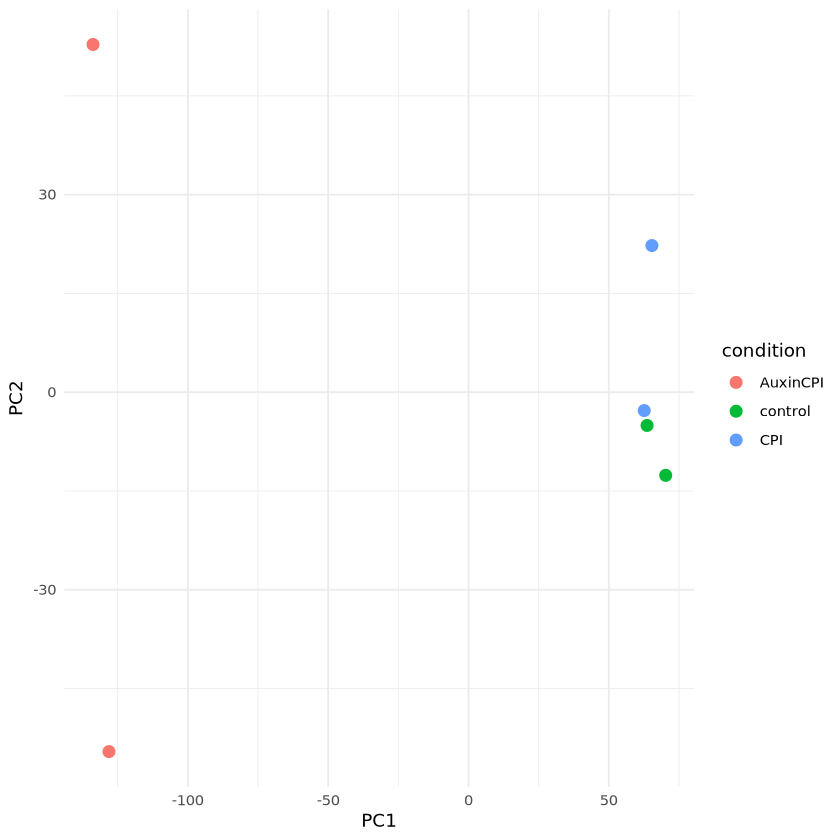

In [3]:
# Load libraries
library(DESeq2)
library(ggplot2)

# Define sample metadata
coldata <- data.frame(condition = factor(c("AuxinCPI", "AuxinCPI", "CPI", "CPI", "control", "control")))
rownames(coldata) <- colnames(counts)

# Create DESeq2 dataset
dds <- DESeqDataSetFromMatrix(countData = counts,
                              colData = coldata,
                              design = ~ condition)

# Regularized log transformation
rld <- rlog(dds, blind = TRUE)

# Transpose: samples as rows, genes as columns
mat <- t(assay(rld))

# Filter out genes (columns) with zero variance
mat_filtered <- mat[, apply(mat, 2, var) != 0]

# PCA
pca <- prcomp(mat_filtered, scale. = TRUE)
pca_df <- as.data.frame(pca$x)
pca_df$condition <- coldata$condition

# Plot PCA
ggplot(pca_df, aes(x = PC1, y = PC2, color = condition)) +
  geom_point(size = 3) +
  theme_minimal()


using ntop=500 top features by variance



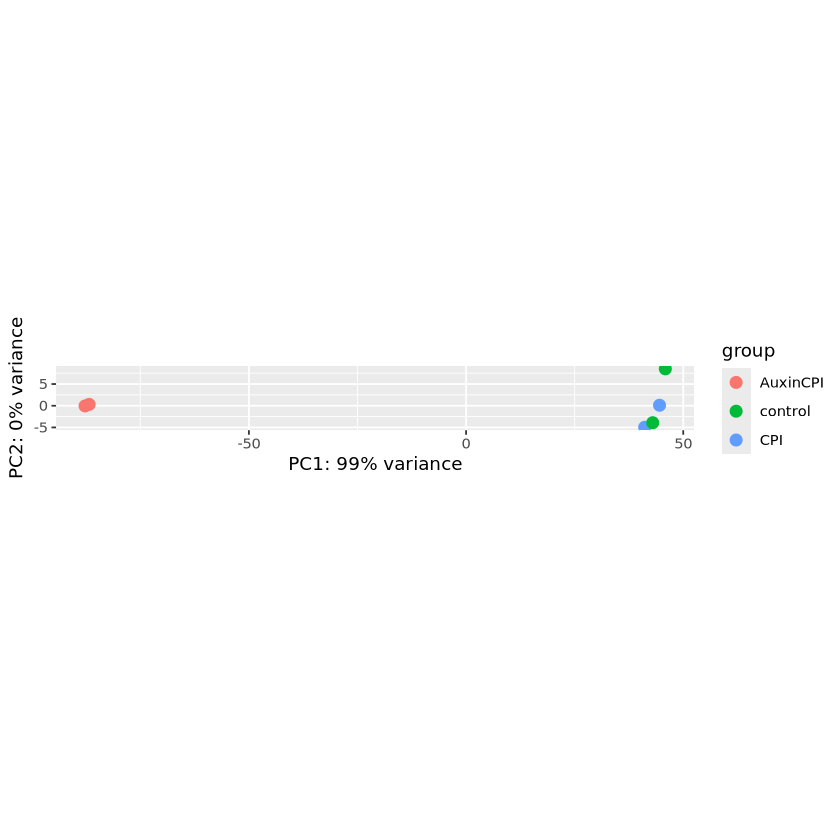

In [4]:
# PCA with DESeq2 built-in function
plotPCA(rld, intgroup = "condition")

#### subset

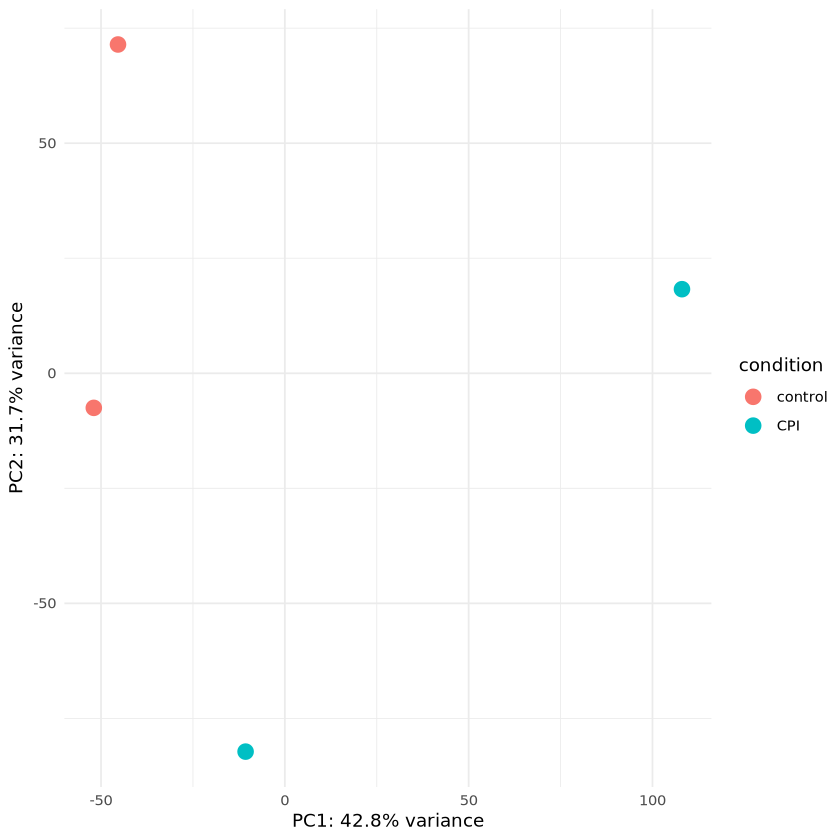

In [5]:
# Subset to CPI and control samples only
counts_cpi_ctrl <- counts[, c("S57", "S58", "S59", "S60")]

# Define sample metadata
condition <- c("CPI", "CPI", "control", "control")
coldata <- data.frame(condition = factor(condition))
rownames(coldata) <- colnames(counts_cpi_ctrl)

# Create DESeq2 dataset
library(DESeq2)
dds <- DESeqDataSetFromMatrix(countData = counts_cpi_ctrl,
                              colData = coldata,
                              design = ~ condition)

# Apply variance-stabilizing transformation (or use rlog if preferred)
vst_mat <- assay(vst(dds, blind = TRUE))

# Transpose: samples as rows
mat <- t(vst_mat)

# Remove genes with zero variance
mat <- mat[, apply(mat, 2, var) != 0]

# Run PCA
pca <- prcomp(mat, scale. = TRUE)
pca_df <- as.data.frame(pca$x)
pca_df$condition <- condition

# Plot PCA
library(ggplot2)
ggplot(pca_df, aes(x = PC1, y = PC2, color = condition)) +
  geom_point(size = 4) +
  theme_minimal() +
  xlab(paste0("PC1: ", round(100 * summary(pca)$importance[2, 1], 1), "% variance")) +
  ylab(paste0("PC2: ", round(100 * summary(pca)$importance[2, 2], 1), "% variance"))

  it appears that the last variable in the design formula, 'condition',
  has a factor level, 'control', which is not the reference level. we recommend
  to use factor(...,levels=...) or relevel() to set this as the reference level
  before proceeding. for more information, please see the 'Note on factor levels'
  in vignette('DESeq2').



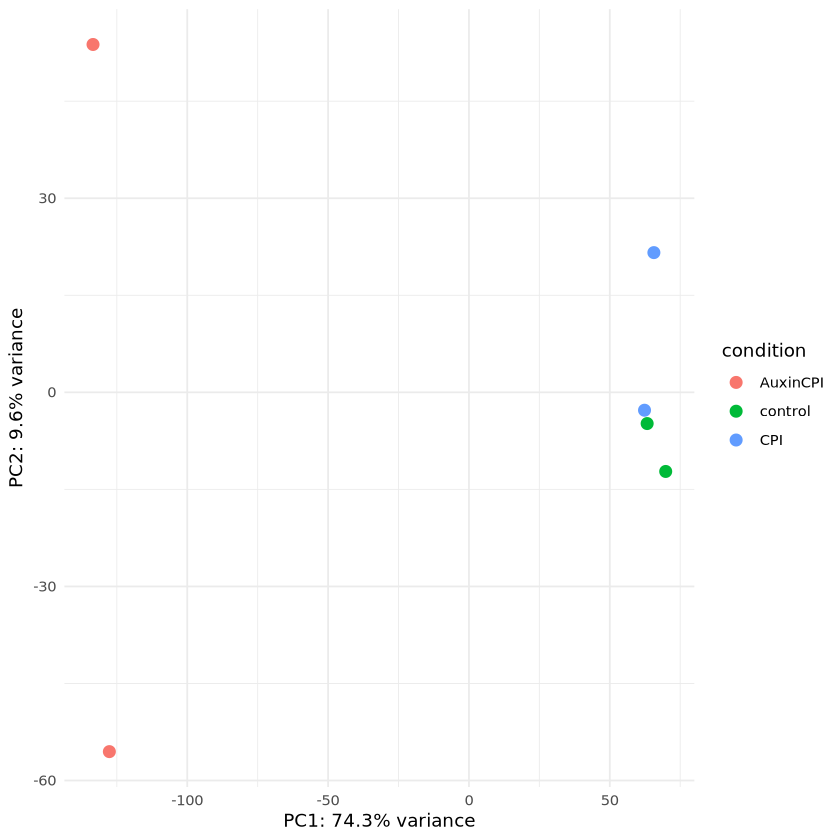

In [6]:
# Load libraries
library(DESeq2)
library(ggplot2)
# Define sample metadata
coldata <- data.frame(condition = factor(c("AuxinCPI", "AuxinCPI", "CPI", "CPI", "control", "control")))
rownames(coldata) <- colnames(counts)

# Create DESeq2 dataset
dds <- DESeqDataSetFromMatrix(countData = counts,
                              colData = coldata,
                              design = ~ condition)

# Apply VST (variance stabilizing transformation)
vst_mat <- assay(vst(dds, blind = TRUE))

# Transpose: samples as rows, genes as columns
mat <- t(vst_mat)

# Remove genes with zero variance
gene_vars <- apply(mat, 2, var)
mat_filtered <- mat[, gene_vars != 0]

# PCA
pca <- prcomp(mat_filtered, scale. = TRUE)
pca_df <- as.data.frame(pca$x)
pca_df$condition <- coldata[match(rownames(pca_df), rownames(coldata)), "condition"]

# Plot PCA
ggplot(pca_df, aes(x = PC1, y = PC2, color = condition)) +
  geom_point(size = 3) +
  theme_minimal() +
  xlab(paste0("PC1: ", round(100 * summary(pca)$importance[2, 1], 1), "% variance")) +
  ylab(paste0("PC2: ", round(100 * summary(pca)$importance[2, 2], 1), "% variance"))

  it appears that the last variable in the design formula, 'condition',
  has a factor level, 'control', which is not the reference level. we recommend
  to use factor(...,levels=...) or relevel() to set this as the reference level
  before proceeding. for more information, please see the 'Note on factor levels'
  in vignette('DESeq2').



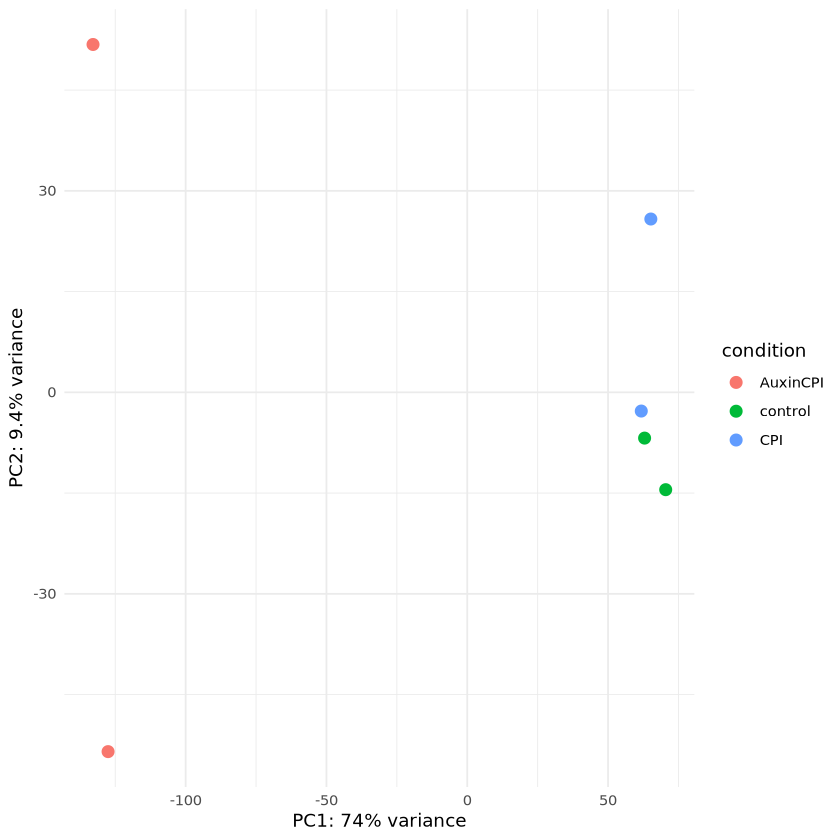

In [7]:
# Load libraries
library(DESeq2)
library(ggplot2)

# Prepare coldata
coldata <- data.frame(condition = factor(c("AuxinCPI", "AuxinCPI", "CPI", "CPI", "control", "control")))
rownames(coldata) <- colnames(counts)

# Create DESeq2 object and estimate size factors
dds <- DESeqDataSetFromMatrix(countData = counts, colData = coldata, design = ~ condition)
dds <- estimateSizeFactors(dds)

# Log-transform normalized counts
log_counts <- log2(counts(dds, normalized = TRUE) + 1)

# Transpose for PCA: samples as rows
mat <- t(log_counts)

# Remove genes with zero variance
gene_vars <- apply(mat, 2, var)
mat_filtered <- mat[, gene_vars != 0]

# Run PCA
pca <- prcomp(mat_filtered, scale. = TRUE)
pca_df <- as.data.frame(pca$x)
pca_df$condition <- coldata[match(rownames(pca_df), rownames(coldata)), "condition"]

# Plot PCA
ggplot(pca_df, aes(x = PC1, y = PC2, color = condition)) +
  geom_point(size = 3) +
  theme_minimal() +
  xlab(paste0("PC1: ", round(100 * summary(pca)$importance[2, 1], 1), "% variance")) +
  ylab(paste0("PC2: ", round(100 * summary(pca)$importance[2, 2], 1), "% variance"))

In [8]:
# control_vs_cpi to do
# Load DE result file
df <- read.table("/usr/users/papantonis1/aman/rnaseq_data/irnaseq_results/control_vs_cpi.txt",
                 header = TRUE, sep = "\t", stringsAsFactors = FALSE)

# Extract only the sample-level expression values
counts <- df[, c("X.usr.users.papantonis1.aman.rnaseq_data.star_results.S57_Aligned.sortedByCoord.out.bam",
                 "X.usr.users.papantonis1.aman.rnaseq_data.star_results.S58_Aligned.sortedByCoord.out.bam",
                 "X.usr.users.papantonis1.aman.rnaseq_data.star_results.S59_Aligned.sortedByCoord.out.bam",
                 "X.usr.users.papantonis1.aman.rnaseq_data.star_results.S60_Aligned.sortedByCoord.out.bam")]

# Rename columns to sample IDs
colnames(counts) <- c("S57", "S58", "S59", "S60")

# Set rownames to gene symbols (or RefSeq if you prefer)
rownames(counts) <- df$Symbol

In [9]:
counts

,S57,S58,S59,S60
,<dbl>,<dbl>,<dbl>,<dbl>
NAT2,-3.4315243,-3.4315243,-3.4315243,-3.43152430
ACAT1,5.1382301,5.3311482,4.9370255,5.04467817
SGCA,-1.9426053,-3.4315243,-3.4315243,-1.73531767
ADRB3,-3.4315243,-3.4315243,-3.4315243,-3.43152430
ABCD1,4.8103790,4.8664755,4.6055814,4.74849253
ALDOB,-3.4315243,-3.4315243,-3.4315243,-3.43152430
APOC3,-3.4315243,-3.4315243,-3.4315243,-3.43152430
APOH,-3.4315243,-3.4315243,-2.5199918,-3.43152430
FAS,4.6245488,4.7391934,4.8230330,4.95576593


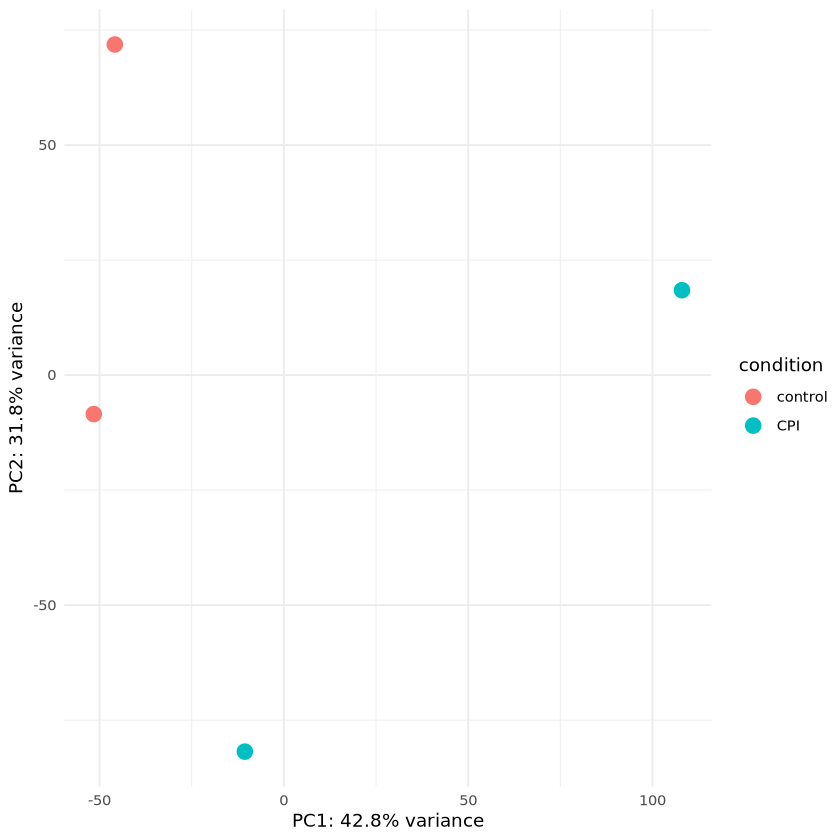

In [10]:
# Transpose: samples as rows
mat <- t(counts)

# Remove genes with zero variance
mat <- mat[, apply(mat, 2, var) != 0]

# Run PCA
pca <- prcomp(mat, scale. = TRUE)
pca_df <- as.data.frame(pca$x)

# Assign condition labels
pca_df$condition <- c("CPI", "CPI", "control", "control")

# Plot
ggplot(pca_df, aes(x = PC1, y = PC2, color = condition)) +
  geom_point(size = 4) +
  theme_minimal() +
  xlab(paste0("PC1: ", round(100 * summary(pca)$importance[2, 1], 1), "% variance")) +
  ylab(paste0("PC2: ", round(100 * summary(pca)$importance[2, 2], 1), "% variance"))

---

In [11]:
# Read raw table
df <- read.table("/usr/users/papantonis1/aman/rnaseq_data/irnaseq_results/all_samples_counts_exons.txt", header = TRUE, sep = "\t", stringsAsFactors = FALSE)

# Extract *only* count columns — from column 9 onwards
counts <- df[, 9:ncol(df)]

# Rename columns to match samples
colnames(counts) <- c("S55", "S56", "S57", "S58", "S59", "S60")

# Set rownames to gene symbols (or RefSeq if preferred)
rownames(counts) <- df$Symbol


In [12]:
counts # this is the cout matrix

,S55,S56,S57,S58,S59,S60
,<int>,<int>,<int>,<int>,<int>,<int>
NAT2,3,14,8,2,10,0
ACADS,481,473,335,318,290,202
ACAT1,946,1251,816,908,858,658
ACVRL1,0,0,1,4,1,2
PSEN1,2947,3491,4182,4052,3451,2774
SGCA,10,10,0,0,0,0
ADRB2,10,4,6,17,4,2
ADRB3,10,5,0,0,0,2
AGXT,8,4,2,6,1,3


  it appears that the last variable in the design formula, 'condition',
  has a factor level, 'control', which is not the reference level. we recommend
  to use factor(...,levels=...) or relevel() to set this as the reference level
  before proceeding. for more information, please see the 'Note on factor levels'
  in vignette('DESeq2').



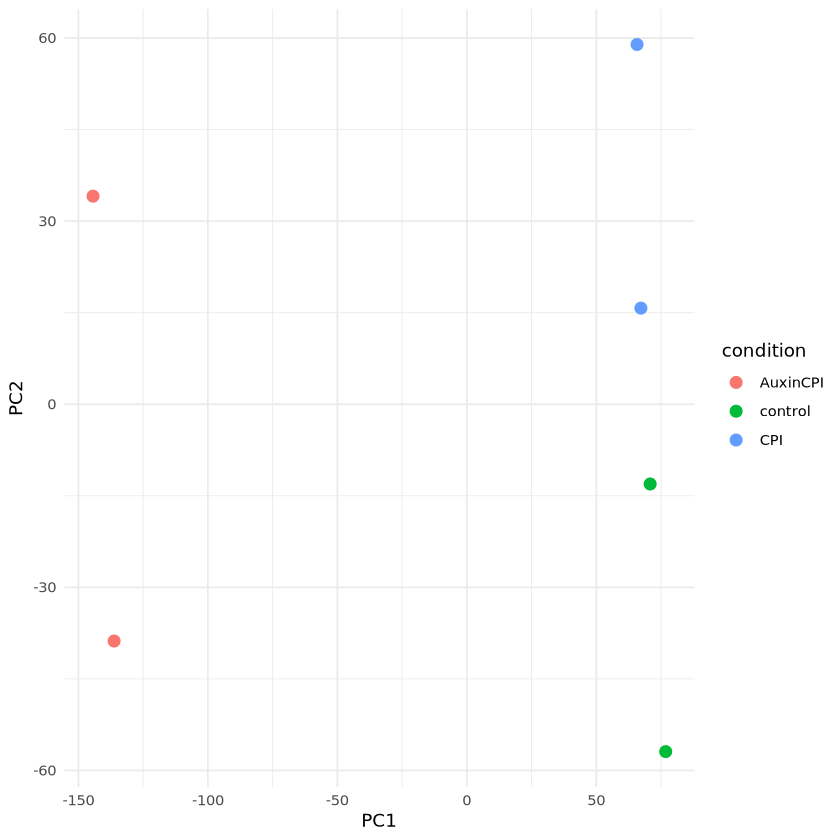

In [13]:
# Load libraries
library(DESeq2)
library(ggplot2)

# Define sample metadata
coldata <- data.frame(condition = factor(c("AuxinCPI", "AuxinCPI", "CPI", "CPI", "control", "control")))
rownames(coldata) <- colnames(counts)

# Create DESeq2 dataset
dds <- DESeqDataSetFromMatrix(countData = counts,
                              colData = coldata,
                              design = ~ condition)

# Regularized log transformation
rld <- rlog(dds, blind = TRUE)

# Transpose: samples as rows, genes as columns
mat <- t(assay(rld))

# Filter out genes (columns) with zero variance
mat_filtered <- mat[, apply(mat, 2, var) != 0]

# PCA
pca <- prcomp(mat_filtered, scale. = TRUE)
pca_df <- as.data.frame(pca$x)
pca_df$condition <- coldata$condition

# Plot PCA
ggplot(pca_df, aes(x = PC1, y = PC2, color = condition)) +
  geom_point(size = 3) +
  theme_minimal()

using ntop=500 top features by variance



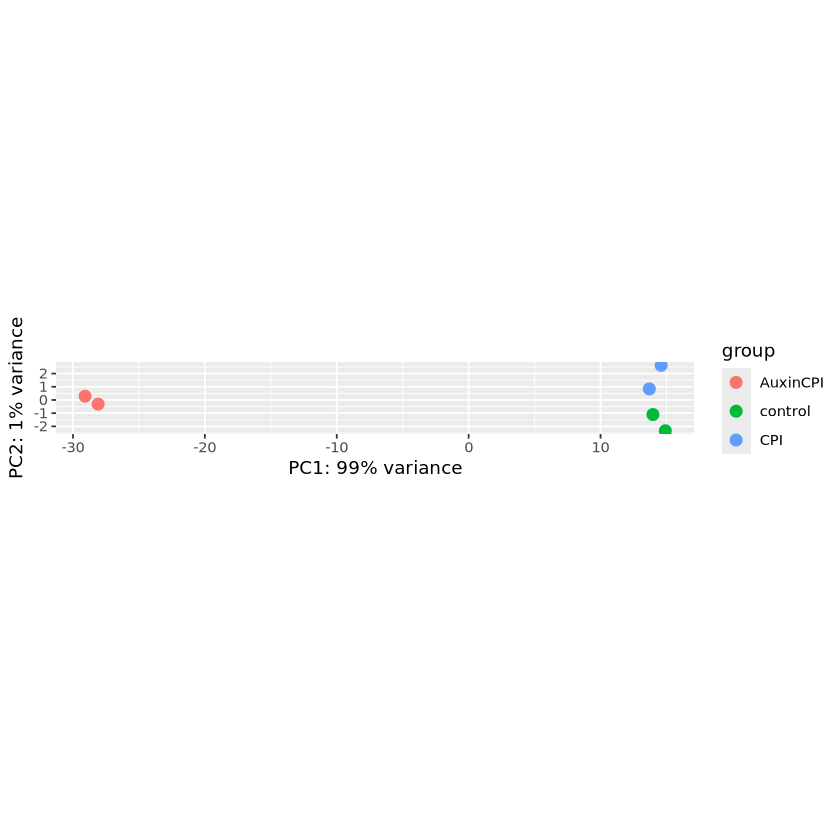

In [14]:
# PCA with DESeq2 built-in function
plotPCA(rld, intgroup = "condition")

### Subset

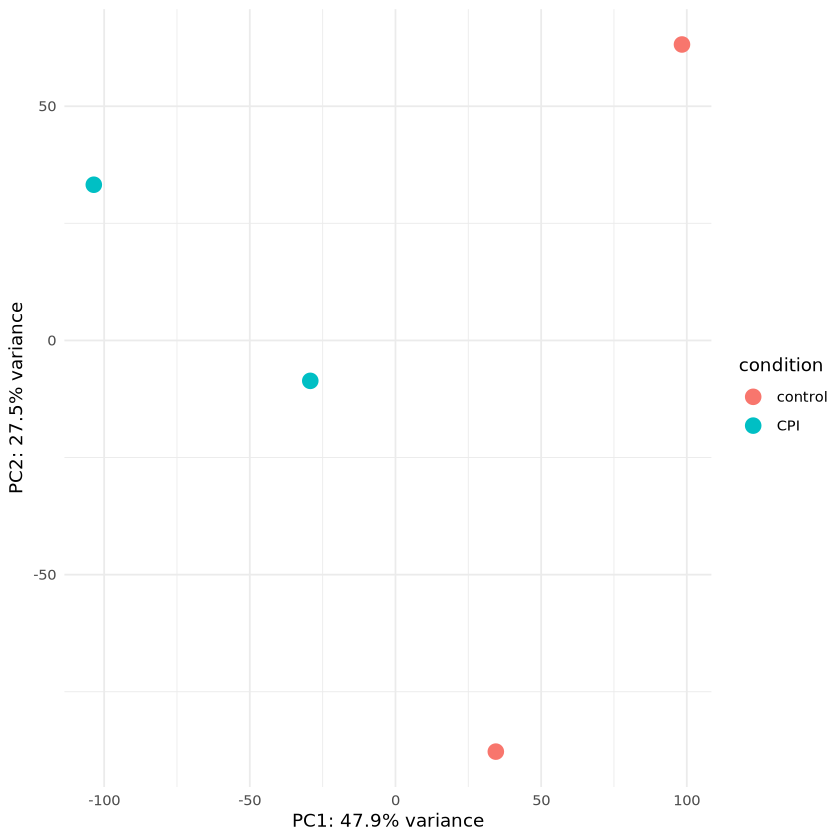

In [15]:
# Subset to CPI and control samples only
counts_cpi_ctrl <- counts[, c("S57", "S58", "S59", "S60")]

# Define sample metadata
condition <- c("CPI", "CPI", "control", "control")
coldata <- data.frame(condition = factor(condition))
rownames(coldata) <- colnames(counts_cpi_ctrl)

# Create DESeq2 dataset
library(DESeq2)
dds <- DESeqDataSetFromMatrix(countData = counts_cpi_ctrl,
                              colData = coldata,
                              design = ~ condition)

# Apply variance-stabilizing transformation (or use rlog if preferred)
vst_mat <- assay(vst(dds, blind = TRUE))

# Transpose: samples as rows
mat <- t(vst_mat)

# Remove genes with zero variance
mat <- mat[, apply(mat, 2, var) != 0]

# Run PCA
pca <- prcomp(mat, scale. = TRUE)
pca_df <- as.data.frame(pca$x)
pca_df$condition <- condition

# Plot PCA
library(ggplot2)
ggplot(pca_df, aes(x = PC1, y = PC2, color = condition)) +
  geom_point(size = 4) +
  theme_minimal() +
  xlab(paste0("PC1: ", round(100 * summary(pca)$importance[2, 1], 1), "% variance")) +
  ylab(paste0("PC2: ", round(100 * summary(pca)$importance[2, 2], 1), "% variance"))

  it appears that the last variable in the design formula, 'condition',
  has a factor level, 'control', which is not the reference level. we recommend
  to use factor(...,levels=...) or relevel() to set this as the reference level
  before proceeding. for more information, please see the 'Note on factor levels'
  in vignette('DESeq2').



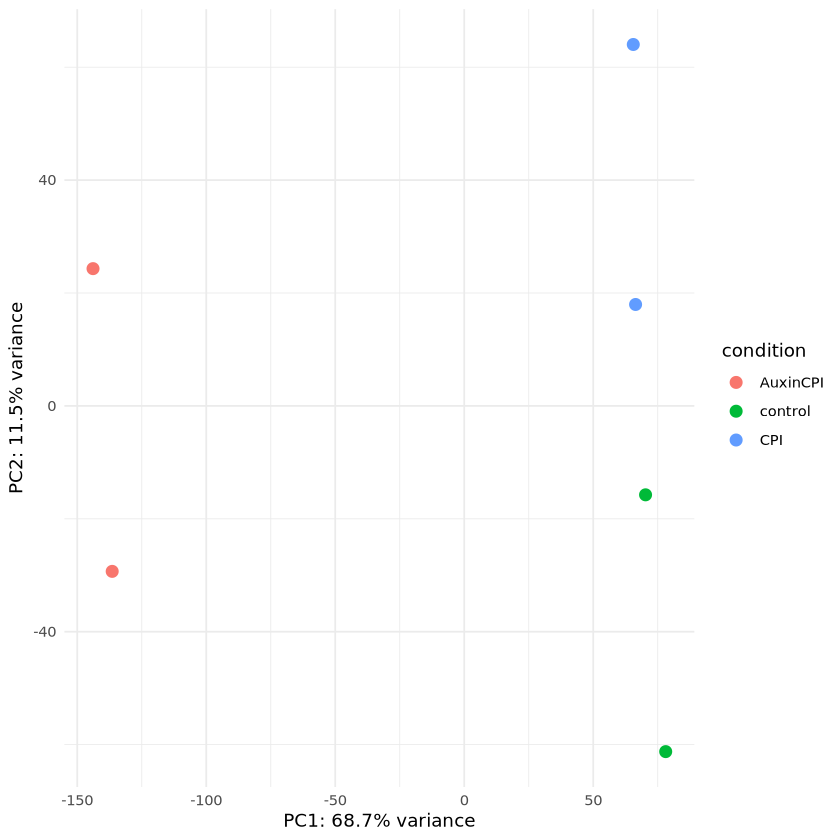

In [16]:
# Load libraries
library(DESeq2)
library(ggplot2)
# Define sample metadata
coldata <- data.frame(condition = factor(c("AuxinCPI", "AuxinCPI", "CPI", "CPI", "control", "control")))
rownames(coldata) <- colnames(counts)

# Create DESeq2 dataset
dds <- DESeqDataSetFromMatrix(countData = counts,
                              colData = coldata,
                              design = ~ condition)

# Apply VST (variance stabilizing transformation)
vst_mat <- assay(vst(dds, blind = TRUE))

# Transpose: samples as rows, genes as columns
mat <- t(vst_mat)

# Remove genes with zero variance
gene_vars <- apply(mat, 2, var)
mat_filtered <- mat[, gene_vars != 0]

# PCA
pca <- prcomp(mat_filtered, scale. = TRUE)
pca_df <- as.data.frame(pca$x)
pca_df$condition <- coldata[match(rownames(pca_df), rownames(coldata)), "condition"]

# Plot PCA
ggplot(pca_df, aes(x = PC1, y = PC2, color = condition)) +
  geom_point(size = 3) +
  theme_minimal() +
  xlab(paste0("PC1: ", round(100 * summary(pca)$importance[2, 1], 1), "% variance")) +
  ylab(paste0("PC2: ", round(100 * summary(pca)$importance[2, 2], 1), "% variance"))